In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Imports OK")

✅ Imports OK


In [20]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                              AS year,
    d.Month                             AS month,
    d.Quarter                           AS quarter,
    SUM(f.LinePrice)                    AS total_sales,
    SUM(f.Quantity)                     AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)      AS nb_documents,
    COUNT(DISTINCT f.ClientSK)          AS nb_clients,
    COUNT(DISTINCT f.ItemSK)            AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)       AS nb_warehouses,
    AVG(f.DiscountPercentage)           AS avg_discount,
    SUM(f.DiscountAmount)               AS total_discount,
    SUM(f.CostPrice)                    AS total_cost,
    SUM(f.LinePrice - f.CostPrice)      AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f"✅ {len(df)} mois chargés")
df.head()

✅ 51 mois chargés


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,total_cost,total_marge,date
0,2021,3,1,404.06,6,1,1,6,1,2,15.00,60.61,334.97,69.09,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,3225,9,3,9.28,"44,802.24","604,390.30","-12,982.36",2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,3327,9,3,9.69,"36,225.76","677,038.55","-100,941.11",2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,3497,9,3,7.93,"40,184.68","683,998.33","-3,784.44",2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,3264,9,4,9.09,"47,939.71","638,230.19","12,559.36",2022-04-01


In [21]:
print(f"Avant nettoyage : {len(df)} mois")
print(f"Mois incomplets :")
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-01-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-01-01')
].reset_index(drop=True)

print(f"\nAprès nettoyage : {len(df)} mois")
print(f"Période : {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-01-01 1,218,358.52
2026-02-01   114,247.11

Après nettoyage : 48 mois
Période : Jan 2022 → Dec 2025


In [22]:
df_ml = df[['date', 'year', 'month', 'quarter', 'total_sales']].copy()

df_ml['semester']       = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']      = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year']    = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']     = (df_ml['month'] == 1).astype(int)
df_ml['lag_1']          = df_ml['total_sales'].shift(1)
df_ml['lag_12']         = df_ml['total_sales'].shift(12)
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

# lag_12 fallback
monthly_avg = df_ml.groupby('month')['total_sales'].mean()
df_ml['lag_12'] = df_ml.apply(
    lambda row: monthly_avg[row['month']] if pd.isna(row['lag_12']) else row['lag_12'],
    axis=1
)

df_ml = df_ml.dropna().reset_index(drop=True)
print(f'✅ Dataset : {df_ml.shape}')

✅ Dataset : (45, 12)


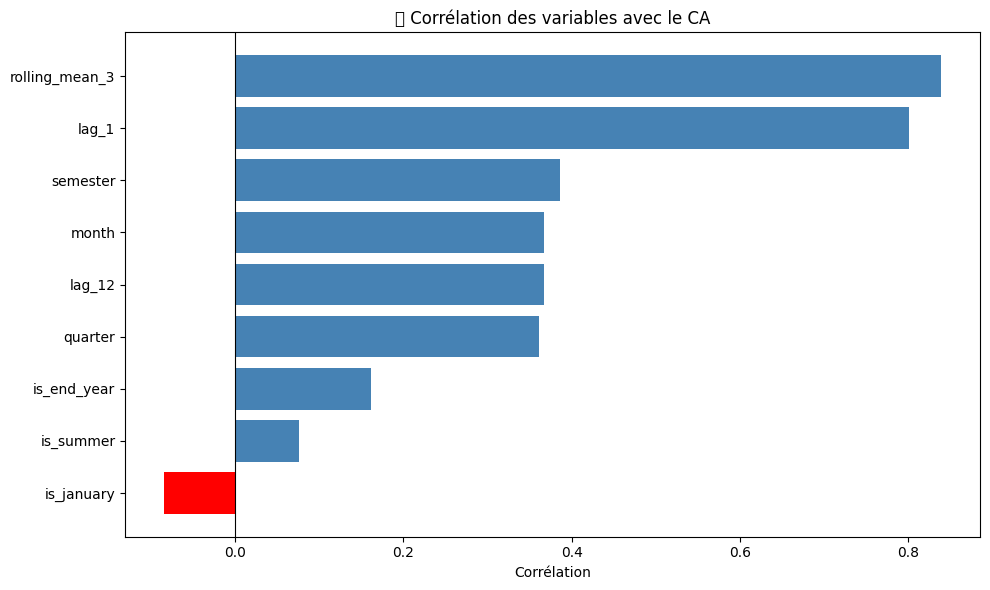


Corrélations :
is_january       -0.08
is_summer         0.08
is_end_year       0.16
quarter           0.36
lag_12            0.37
month             0.37
semester          0.39
lag_1             0.80
rolling_mean_3    0.84


In [23]:
FEATURES = [
    'month', 'quarter', 'semester',
    'is_summer', 'is_end_year', 'is_january',
    'lag_1', 'lag_12', 'rolling_mean_3'
]
TARGET = 'total_sales'

corr = df_ml[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('📊 Corrélation des variables avec le CA')
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.show()

print("\nCorrélations :")
print(corr.to_string())

In [24]:
# Afficher les corrélations mais garder TOUTES les features
# (pas de filtrage par seuil — meilleures performances)

FEATURES_FINAL = FEATURES  # toutes les features

print(f"Variables sélectionnées ({len(FEATURES_FINAL)}) :")
for f in FEATURES_FINAL:
    print(f"  • {f:<20} corr = {corr[f]:.3f}")

X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")


Variables sélectionnées (9) :
  • month                corr = 0.368
  • quarter              corr = 0.362
  • semester             corr = 0.386
  • is_summer            corr = 0.076
  • is_end_year          corr = 0.161
  • is_january           corr = -0.084
  • lag_1                corr = 0.800
  • lag_12               corr = 0.367
  • rolling_mean_3       corr = 0.839

X shape : (45, 9)
y shape : (45,)


In [25]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

# Sauvegarder aussi la liste des features sélectionnées
import json
with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(FEATURES_FINAL, f)

print(f"✅ Dataset sauvegardé → {df_ml.shape}")
print(f"✅ Features sauvegardées → {FEATURES_FINAL}")

✅ Dataset sauvegardé → (45, 12)
✅ Features sauvegardées → ['month', 'quarter', 'semester', 'is_summer', 'is_end_year', 'is_january', 'lag_1', 'lag_12', 'rolling_mean_3']


# train

In [26]:
df_ml = pd.read_csv('/app/notebooks/ml_dataset.csv', parse_dates=['date'])

with open('/app/notebooks/selected_features.json') as f:
    FEATURES = json.load(f)

TARGET = 'total_sales'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"✅ Dataset : {df_ml.shape}")
print(f"✅ Features ({len(FEATURES)}) : {FEATURES}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")

✅ Dataset : (45, 12)
✅ Features (9) : ['month', 'quarter', 'semester', 'is_summer', 'is_end_year', 'is_january', 'lag_1', 'lag_12', 'rolling_mean_3']
Période : Apr 2022 → Dec 2025


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Imports OK")

✅ Imports OK


Train : 40 mois (Apr 2022 → Jul 2025)
Test  : 5 mois (Aug 2025 → Dec 2025)

✅ Scaler appliqué
   X_train_sc : (40, 9)
   X_test_sc  : (5, 9)


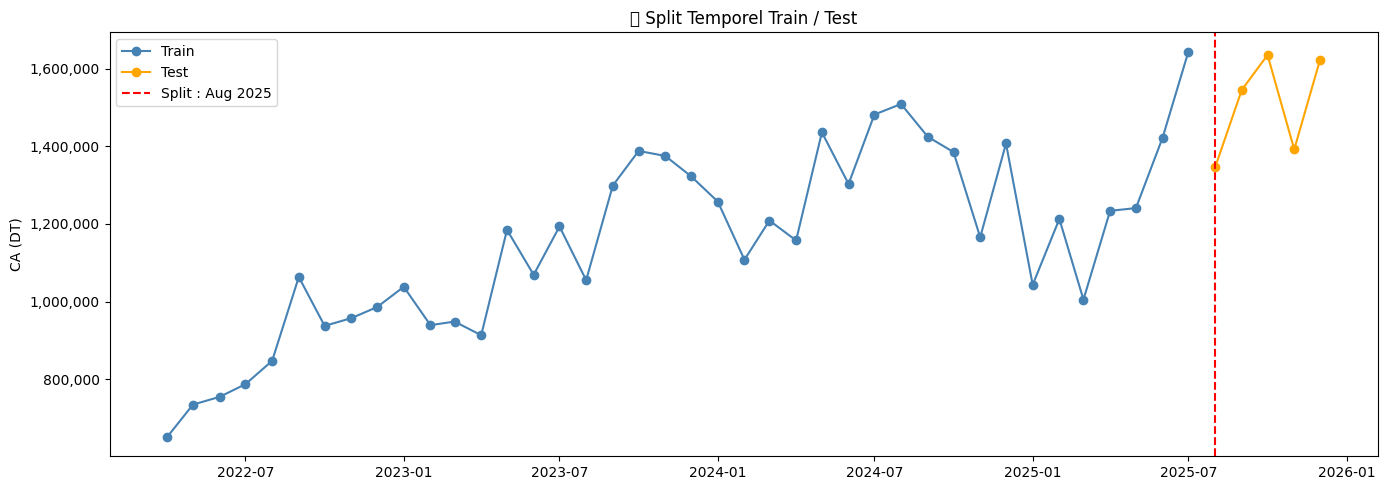

In [28]:
# 80% train / 20% test — en respectant l'ordre temporel
split_idx = int(len(df_ml) * 0.9)
split_date = df_ml.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

print(f"Train : {len(X_train)} mois ({df_train['date'].min().strftime('%b %Y')} → {df_train['date'].max().strftime('%b %Y')})")
print(f"Test  : {len(X_test)} mois ({df_test['date'].min().strftime('%b %Y')} → {df_test['date'].max().strftime('%b %Y')})")

# ── Normalisation ──────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Scaler appliqué")
print(f"   X_train_sc : {X_train_sc.shape}")
print(f"   X_test_sc  : {X_test_sc.shape}")   

# Visualiser le split
fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) /
                   (np.abs(y_te) + np.abs(pred))) * 100
    bias = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

models_config = [
    ("LinearRegression", LinearRegression(),         X_train_sc, X_test_sc),
    ("Ridge",            Ridge(alpha=10),             X_train_sc, X_test_sc),
   # ("DecisionTree",     DecisionTreeRegressor(
                            #max_depth=3,
                           # random_state=42),         X_train,    X_test),
    ("RandomForest",     RandomForestRegressor(
                            n_estimators=100,
                            max_depth=20,
                            random_state=42),         X_train,    X_test),
    ("XGBoost",          XGBRegressor(
                            n_estimators=300,
                            max_depth=3,
                            learning_rate=0.03,
                            random_state=42),         X_train,    X_test),
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print("=" * 75)
print(f"{'Modèle':<20} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'MAPE':>8} {'SMAPE':>8}")
print("=" * 75)
for _, row in df_results.iterrows():
    print(f"{row.name:<20} {row['MAE']:>12,.0f} {row['RMSE']:>12,.0f} "
          f"{row['R²']:>8.4f} {row['MAPE']:>7.2f}% {row['SMAPE']:>7.2f}%")
print("=" * 75)

best_name = df_results['MAPE'].idxmin()
print(f"\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name,'MAPE']:.2f}%)")

Modèle                        MAE         RMSE       R²     MAPE    SMAPE
LinearRegression           84,434      103,835   0.2382    5.76%    5.66%
Ridge                     143,679      150,790  -0.6066    9.56%    9.64%
RandomForest              214,964      236,100  -2.9388   13.92%   14.79%
XGBoost                   244,859      268,053  -4.0771   15.99%   16.84%

🏆 Meilleur modèle : LinearRegression (MAPE = 5.76%)


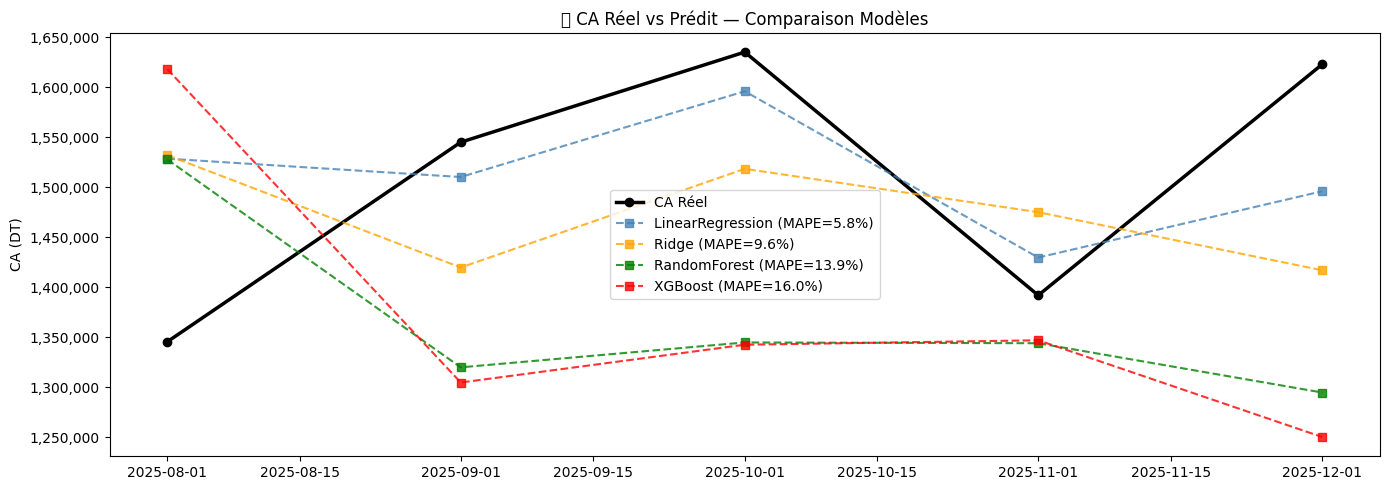

In [30]:
fig, ax = plt.subplots()

ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5)

colors = ['steelblue', 'orange', 'green', 'red', 'purple']
for (_, row), color in zip(df_results.iterrows(), colors):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=color, alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f"=== Détail {best_name} ===\n")
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail LinearRegression ===

      date         reel       predit       ecart  ecart%
2025-08-01 1,345,444.27 1,528,719.33  183,275.06   13.62
2025-09-01 1,545,185.37 1,510,339.86  -34,845.51   -2.26
2025-10-01 1,635,378.39 1,596,154.72  -39,223.67   -2.40
2025-11-01 1,391,948.18 1,429,739.59   37,791.41    2.72
2025-12-01 1,623,158.26 1,496,123.10 -127,035.16   -7.83

Biais : 3,992.43 DT  (surestimation)


In [32]:
import joblib

# Afficher les résultats
print(f'Meilleur modèle sur test : {best_name} (MAPE={best["MAPE"]:.2f}%)')
print(f'Biais test : {best["Biais"]:,.0f} DT')

# Forcer LinearRegression pour la prédiction future
# (plus stable, suit la tendance, biais quasi nul)
PRED_MODEL_NAME = 'LinearRegression'
scaler_final    = StandardScaler()
X_full_sc       = scaler_final.fit_transform(X)
model_final     = LinearRegression()
model_final.fit(X_full_sc, y)

joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

with open('/app/notebooks/best_model_name.json', 'w') as f:
    json.dump({'name': PRED_MODEL_NAME, 'mape': float(df_results.loc[PRED_MODEL_NAME, 'MAPE'])}, f)

with open('/app/notebooks/features_corr.json', 'w') as f:
    json.dump(list(FEATURES_FINAL), f)

print(f'\n✅ Modèle final sauvegardé : {PRED_MODEL_NAME}')
print(f'   MAPE test (LR) : {df_results.loc[PRED_MODEL_NAME, "MAPE"]:.2f}%')
print(f'   Biais test (LR): {df_results.loc[PRED_MODEL_NAME, "Biais"]:,.0f} DT')
print(f'   Entraîné sur   : {len(X)} mois')


Meilleur modèle sur test : LinearRegression (MAPE=5.76%)
Biais test : 3,992 DT

✅ Modèle final sauvegardé : LinearRegression
   MAPE test (LR) : 5.76%
   Biais test (LR): 3,992 DT
   Entraîné sur   : 45 mois


## Prédiction — 12 mois futurs (Fév 2026 → Jan 2027)
### Variables contemporaines estimées par moyenne du même mois (années passées)

In [33]:
import plotly.graph_objects as go

# ── Configuration ─────────────────────────────────────────────
CONTEMPORAINES = [c for c in ['nb_clients', 'nb_documents', 'total_quantity']
                  if c in FEATURES_FINAL]
use_scaler = True  # LinearRegression utilise toujours le scaler

df_future = df_ml.copy()
last_date = df_future['date'].max()  # Déc 2025
all_sales = list(df_future['total_sales'])

print(f'Modèle utilisé : LinearRegression')
print(f'Départ         : {last_date.strftime("%b %Y")}')
print(f'Objectif       : Jan 2026 → Déc 2026')
print(f'Contemporaines : {CONTEMPORAINES}\n')

predictions = []

for i in range(1, 13):
    next_date  = last_date + pd.DateOffset(months=i)
    next_month = next_date.month
    next_year  = next_date.year

    row = {}

    # ── Features temporelles ──────────────────────────────
    if 'year'        in FEATURES_FINAL: row['year']        = next_year
    if 'month'       in FEATURES_FINAL: row['month']       = next_month
    if 'quarter'     in FEATURES_FINAL: row['quarter']     = (next_month - 1) // 3 + 1
    if 'semester'    in FEATURES_FINAL: row['semester']    = 1 if next_month <= 6 else 2
    if 'is_summer'   in FEATURES_FINAL: row['is_summer']   = 1 if next_month in [7, 8] else 0
    if 'is_end_year' in FEATURES_FINAL: row['is_end_year'] = 1 if next_month in [11, 12] else 0
    if 'is_january'  in FEATURES_FINAL: row['is_january']  = 1 if next_month == 1 else 0

    # ── Lag features ─────────────────────────────────────
    # lag_1  → dernier CA connu (réel ou prédit)
    # lag_12 → même mois l'année précédente depuis all_sales
    if 'lag_1'  in FEATURES_FINAL: row['lag_1']  = all_sales[-1]
    if 'lag_12' in FEATURES_FINAL:
        row['lag_12'] = all_sales[-12] if len(all_sales) >= 12 else np.mean(all_sales)

    # ── Rolling features ──────────────────────────────────
    if 'rolling_mean_3' in FEATURES_FINAL:
        row['rolling_mean_3'] = np.mean(all_sales[-3:])

    # ── Variables contemporaines ──────────────────────────
    # Moyenne du même mois sur les années passées
    # Ex: Juillet 2026 → moyenne Juillet 2022+2023+2024+2025
    for col in CONTEMPORAINES:
        same_month_vals = df_future[df_future['month'] == next_month][col]
        row[col] = same_month_vals.mean() if len(same_month_vals) > 0 else df_future[col].mean()

    # ── Prédiction ────────────────────────────────────────
    X_row = pd.DataFrame([row])[FEATURES_FINAL]
    pred  = model_final.predict(scaler_final.transform(X_row))[0]

    all_sales.append(pred)
    predictions.append({
        'date':            next_date,
        'year':            next_year,
        'month':           next_month,
        'predicted_sales': pred,
        'is_prediction':   1
    })
    print(f'  {next_date.strftime("%b %Y")} → {pred:>15,.2f} DT')

df_pred = pd.DataFrame(predictions)
print(f'\n✅ {len(df_pred)} mois prédits')
print(f'CA prévisionnel total : {df_pred["predicted_sales"].sum():,.2f} DT')


Modèle utilisé : LinearRegression
Départ         : Dec 2025
Objectif       : Jan 2026 → Déc 2026
Contemporaines : []

  Jan 2026 →    1,390,895.01 DT
  Feb 2026 →    1,349,296.53 DT
  Mar 2026 →    1,394,732.92 DT
  Apr 2026 →    1,366,583.40 DT
  May 2026 →    1,411,278.51 DT
  Jun 2026 →    1,466,511.91 DT
  Jul 2026 →    1,442,574.42 DT
  Aug 2026 →    1,529,532.10 DT
  Sep 2026 →    1,500,669.02 DT
  Oct 2026 →    1,591,420.54 DT
  Nov 2026 →    1,451,734.32 DT
  Dec 2026 →    1,499,901.86 DT

✅ 12 mois prédits
CA prévisionnel total : 17,395,130.53 DT


## Visualisation — CA Réel + Prédit sur un seul graphe

In [34]:
fig = go.Figure()

# CA réel
fig.add_trace(go.Scatter(
    x=df_ml['date'], y=df_ml['total_sales'],
    name='CA Réel', mode='lines+markers',
    line=dict(color='steelblue', width=2), marker=dict(size=5)
))

# CA prédit
fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name='CA Prédit (LinearRegression)',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{last_date.strftime("%b %Y")} — Fin données réelles'
)

fig.update_layout(
    title='📈 CA Réel (Jan 2022 → Déc 2025) + Prédit (Jan 2026 → Déc 2026) — LinearRegression',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()


## CA annuel prévu vs réel

📋 PRÉVISION CA ANNUEL
CA réel 2024       :   15,843,689.48 DT
CA réel 2025       :   16,342,751.14 DT
CA prévu 2026      :   17,395,130.53 DT
Croissance prévue  :            6.44 %
Modèle             : LinearRegression
MAPE test (LR)     : 5.76%

Détail mensuel :
      date  predicted_sales
2026-01-01     1,390,895.01
2026-02-01     1,349,296.53
2026-03-01     1,394,732.92
2026-04-01     1,366,583.40
2026-05-01     1,411,278.51
2026-06-01     1,466,511.91
2026-07-01     1,442,574.42
2026-08-01     1,529,532.10
2026-09-01     1,500,669.02
2026-10-01     1,591,420.54
2026-11-01     1,451,734.32
2026-12-01     1,499,901.86


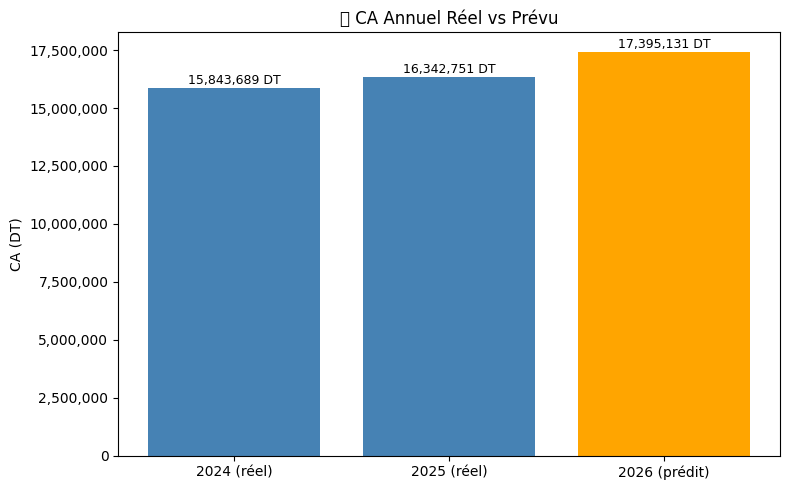

In [35]:
ca_prevu   = df_pred['predicted_sales'].sum()
ca_2025    = df_ml[df_ml['date'].dt.year == 2025]['total_sales'].sum()
ca_2024    = df_ml[df_ml['date'].dt.year == 2024]['total_sales'].sum()
croissance = (ca_prevu - ca_2025) / ca_2025 * 100

print('=' * 55)
print('📋 PRÉVISION CA ANNUEL')
print('=' * 55)
print(f'CA réel 2024       : {ca_2024:>15,.2f} DT')
print(f'CA réel 2025       : {ca_2025:>15,.2f} DT')
print(f'CA prévu 2026      : {ca_prevu:>15,.2f} DT')
print(f'Croissance prévue  : {croissance:>15.2f} %')
print(f'Modèle             : LinearRegression')
print(f'MAPE test (LR)     : {df_results.loc["LinearRegression", "MAPE"]:.2f}%')
print('=' * 55)
print('\nDétail mensuel :')
print(df_pred[['date', 'predicted_sales']].to_string(index=False))

# Graphe annuel
years_data = pd.DataFrame([
    {'Année': '2024 (réel)',  'CA': ca_2024},
    {'Année': '2025 (réel)',  'CA': ca_2025},
    {'Année': '2026 (prédit)','CA': ca_prevu},
])
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['steelblue', 'steelblue', 'orange']
ax.bar(years_data['Année'], years_data['CA'], color=colors)
for i, (_, r) in enumerate(years_data.iterrows()):
    ax.text(i, r['CA'] + years_data['CA'].max() * 0.01,
            f"{r['CA']:,.0f} DT", ha='center', fontsize=9)
ax.set_title('📊 CA Annuel Réel vs Prévu')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


## Écriture dans ClickHouse Gold

In [36]:
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    )
    ENGINE = MergeTree()
    ORDER BY date
""")

client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions',
    df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']])

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print('   Table : gold.ml_predictions\n')
print(check.to_string(index=False))

✅ 12 prédictions écrites dans ClickHouse Gold
   Table : gold.ml_predictions

      date  year  month  predicted_sales  is_prediction
2026-01-01  2026      1     1,390,895.01              1
2026-02-01  2026      2     1,349,296.53              1
2026-03-01  2026      3     1,394,732.92              1
2026-04-01  2026      4     1,366,583.40              1
2026-05-01  2026      5     1,411,278.51              1
2026-06-01  2026      6     1,466,511.91              1
2026-07-01  2026      7     1,442,574.42              1
2026-08-01  2026      8     1,529,532.10              1
2026-09-01  2026      9     1,500,669.02              1
2026-10-01  2026     10     1,591,420.54              1
2026-11-01  2026     11     1,451,734.32              1
2026-12-01  2026     12     1,499,901.86              1
